# Laboratorio 1 — Series de Tiempo
### Data Science | Universidad del Valle de Guatemala 

**Integrantes:** Adrián González, José Ordoñez, Alejandro Anton

Dataset: ingreso mensual de viajeros internacionales a Guatemala (2009-2026).

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
FIGS = "figs"
os.makedirs(FIGS, exist_ok=True)

## Carga de datos

In [2]:
df = pd.read_excel("Base_Migracion_2009-2026jun.xlsx")
print("Dimensiones:", df.shape)
df.dtypes

Dimensiones: (161036, 13)


Año                        int64
Mes cod                    int64
Mes                          str
Vía                          str
Frontera                     str
País                         str
Región                       str
Región dos                   str
Regiones OMT                 str
MCEO                         str
Agrupación Residencia        str
Tipo de Viajero              str
Viajero                  float64
dtype: object

## Limpieza y calidad de datos

Revisamos nulos, duplicados, valores atípicos y consistencia de categorías.

In [3]:
print("--- Nulos por columna ---")
print(df.isna().sum())
print("\n--- Duplicados exactos ---", df.duplicated().sum())

# Fecha de referencia (dia 1 de cada mes)
df["Fecha"] = pd.to_datetime(dict(year=df["Año"], month=df["Mes cod"], day=1))

# Región dos: hay valores '0' y separacion redundante
print("\n--- Valores unicos de 'Región dos' ---")
print(df["Región dos"].value_counts())

--- Nulos por columna ---
Año                      0
Mes cod                  0
Mes                      0
Vía                      0
Frontera                 0
País                     0
Región                   0
Región dos               0
Regiones OMT             0
MCEO                     0
Agrupación Residencia    0
Tipo de Viajero          0
Viajero                  0
dtype: int64



--- Duplicados exactos --- 0

--- Valores unicos de 'Región dos' ---
Región dos
Europa                         54640
América Del Centro             31362
América Del Sur y el Caribe    24734
América Del Norte              17306
Asia                           13247
Otros Paises Del Mundo          8979
Oceanía                         5746
Oriente Medio                   4805
Cruceristas                      196
0                                 13
Cruceros                           8
Name: count, dtype: int64


In [4]:
# Unificamos categorias de cruceros dentro de Región dos
df["Región dos"] = df["Región dos"].replace({"Cruceros": "Cruceristas", "0": "Sin Clasificar"})

# Viajero: cantidad de viajeros, se esperan enteros pero hay decimales -> posible
# resultado de agregaciones/estimaciones oficiales. Revisamos negativos y ceros.
print("Registros con Viajero < 0:", (df["Viajero"] < 0).sum())
print("Registros con Viajero == 0:", (df["Viajero"] == 0).sum())
print("Registros con parte decimal no entera:", (df["Viajero"] % 1 != 0).sum())

Registros con Viajero < 0: 0
Registros con Viajero == 0: 54
Registros con parte decimal no entera: 51272


In [5]:
# Outliers univariados (a nivel de registro) via IQR
q1, q3 = df["Viajero"].quantile([0.25, 0.75])
iqr = q3 - q1
lim_sup = q3 + 3 * iqr
outliers = df[df["Viajero"] > lim_sup]
print(f"Registros por encima de Q3+3*IQR ({lim_sup:.1f}): {len(outliers)} de {len(df)}")
outliers.groupby("Tipo de Viajero")["Viajero"].agg(["count", "mean", "max"])

Registros por encima de Q3+3*IQR (149.6): 21104 de 161036


,count,mean,max
Tipo de Viajero,,,
Cruceristas,203,5439.985222,21680.933573
Excursionista,3991,2201.153453,38463.026064
Turista,13915,2582.886672,83511.000000
Viajero,2995,1366.694064,92336.035067


## Estadísticas descriptivas

In [6]:
print("--- Estadísticas descriptivas de Viajero (nivel registro) ---")
print(df["Viajero"].describe())
print("\n--- Total de viajeros por Tipo de Viajero ---")
df.groupby("Tipo de Viajero")["Viajero"].sum().sort_values(ascending=False)

--- Estadísticas descriptivas de Viajero (nivel registro) ---
count    161036.000000
mean        324.697193
std        2387.745140
min           0.000000
25%           2.000000
50%           7.000000
75%          38.891667
max       92336.035067
Name: Viajero, dtype: float64

--- Total de viajeros por Tipo de Viajero ---


Tipo de Viajero
Turista          3.764273e+07
Excursionista    9.069184e+06
Viajero          4.471622e+06
Cruceristas      1.104402e+06
Name: Viajero, dtype: float64

## Análisis Preliminar de la Serie: Total Mensual de Viajeros Internacionales

In [7]:
import warnings
warnings.filterwarnings("ignore")

In [8]:
# Agregación mensual del total de viajeros internacionales
mensual = (df.groupby(["Año", "Mes cod"])["Viajero"]
             .sum()
             .reset_index())

fechas = pd.to_datetime(dict(year=mensual["Año"], month=mensual["Mes cod"], day=1))
ts = pd.Series(mensual["Viajero"].values, index=pd.DatetimeIndex(fechas, freq="MS"), name="total_viajeros")

print(f"Observaciones: {len(ts)}")
ts.head(10)

Observaciones: 210


2009-01-01    183505.590535
2009-02-01    149426.253908
2009-03-01    174237.227095
2009-04-01    182842.489917
2009-05-01    133194.667651
2009-06-01    156292.128571
2009-07-01    140089.275692
2009-08-01    189382.188376
2009-09-01    135790.188456
2009-10-01    156825.966667
Freq: MS, Name: total_viajeros, dtype: float64

### a. Inicio, fin y frecuencia de la serie

In [9]:
print(f"Inicio:  {ts.index[0]:%B %Y}")
print(f"Fin:     {ts.index[-1]:%B %Y}")
print(f"Frecuencia: {ts.index.freqstr}")
print(f"Total de observaciones: {len(ts)}")

Inicio:  January 2009
Fin:     June 2026
Frecuencia: MS
Total de observaciones: 210


### b. Gráfico de la serie

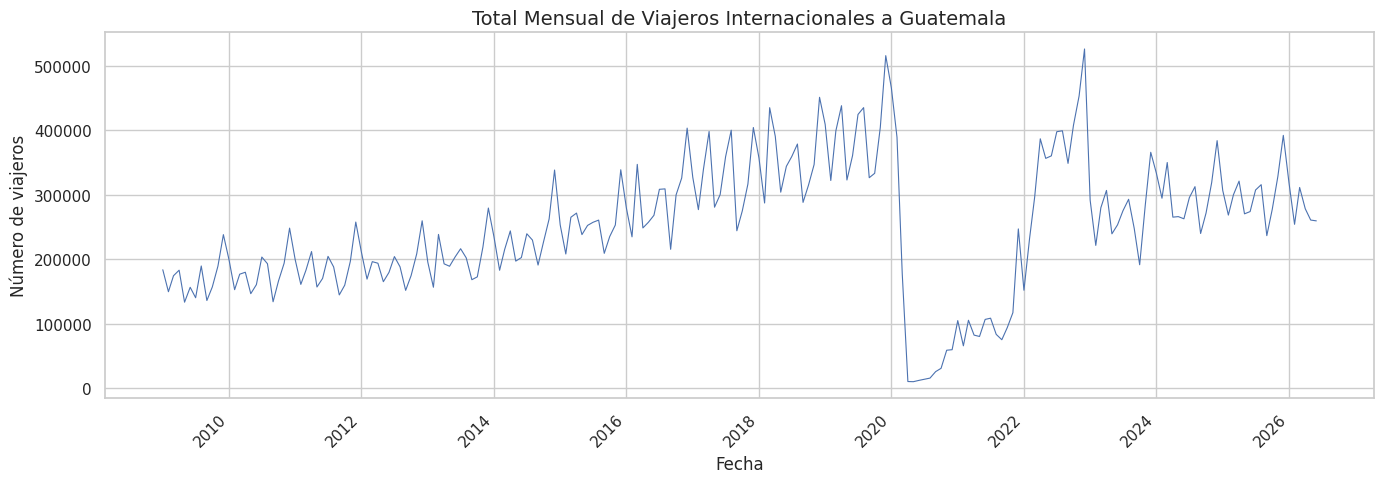

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts.index, ts.values, linewidth=0.8)
ax.set_title("Total Mensual de Viajeros Internacionales a Guatemala", fontsize=14)
ax.set_xlabel("Fecha")
ax.set_ylabel("Número de viajeros")
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.savefig(f"{FIGS}/serie_mensual.png", dpi=150, bbox_inches="tight")
plt.show()

**Observaciones a primera vista:**

- Se observa una **tendencia creciente** general en el número de viajeros internacionales a lo largo de los años.
- Existe un patrón **estacional** claro: cada año se repiten picos y valles en los mismos meses (probablemente asociados a temporadas altas y bajas de turismo).
- Se evidencia una **caída abrupta** alrededor de 2020, correspondiente a la pandemia de COVID-19, que provocó una reducción drástica en los viajes internacionales.
- Tras la pandemia, la serie muestra una **recuperación** acelerada que supera los niveles pre-pandemia.
- La **amplitud** de las oscilaciones estacionales parece aumentar con el tiempo, lo que sugiere que la varianza no es constante (posible heterocedasticidad).

### c. Descomposición de la serie

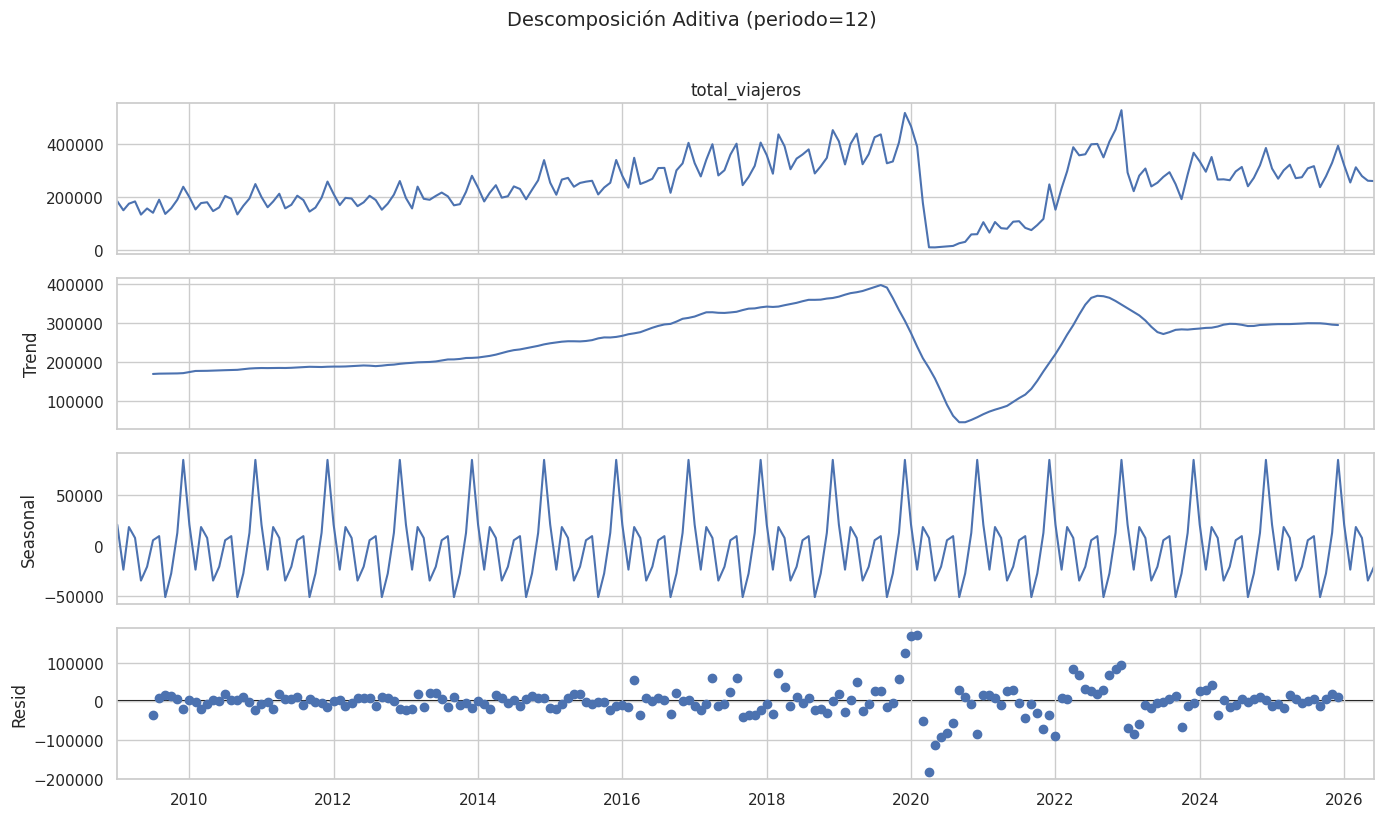

In [11]:
decomp_add = seasonal_decompose(ts, model="additive", period=12)

fig = decomp_add.plot()
fig.set_size_inches(14, 8)
fig.suptitle("Descomposición Aditiva (periodo=12)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGS}/descomposicion_aditiva.png", dpi=150, bbox_inches="tight")
plt.show()

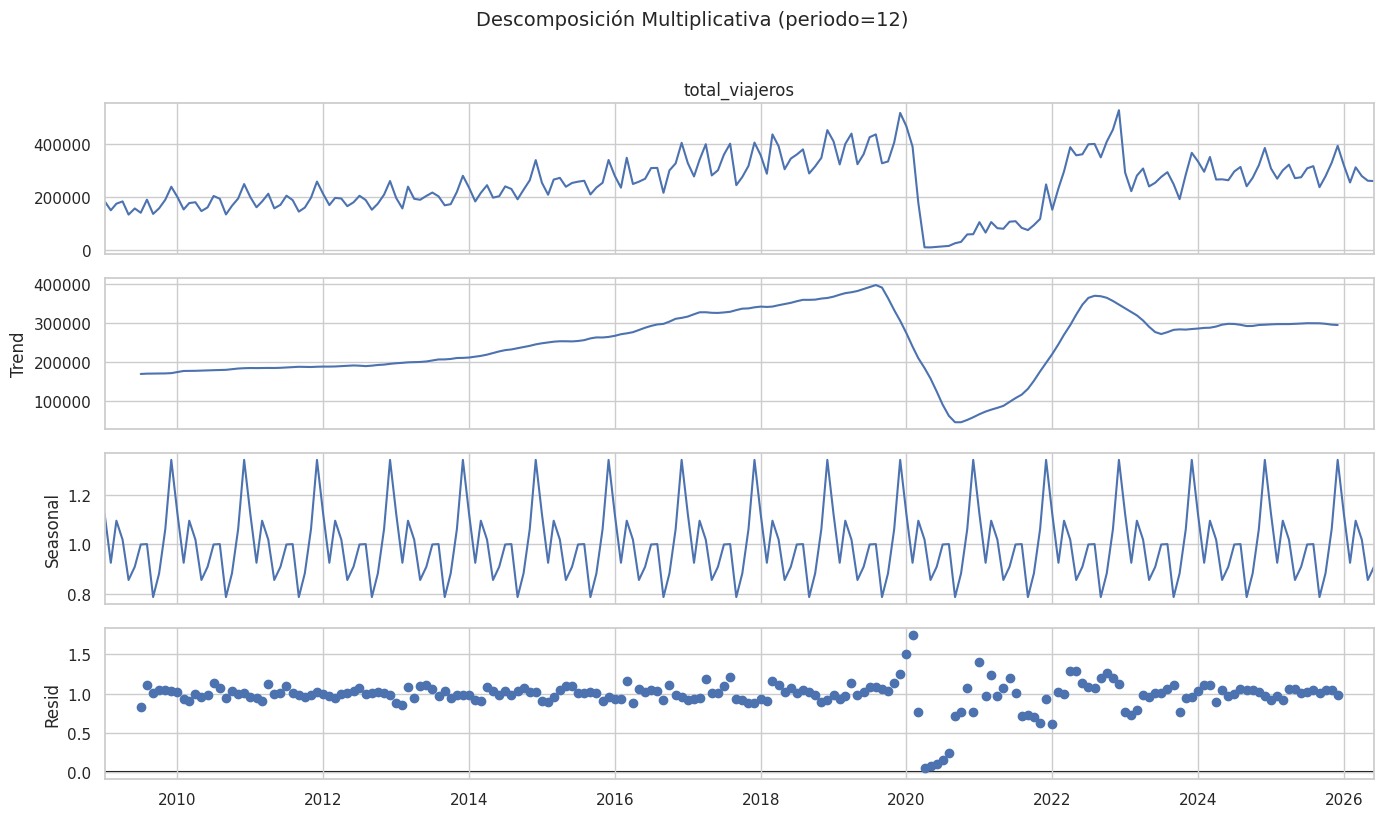

In [12]:
decomp_mul = seasonal_decompose(ts, model="multiplicative", period=12)

fig = decomp_mul.plot()
fig.set_size_inches(14, 8)
fig.suptitle("Descomposición Multiplicativa (periodo=12)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGS}/descomposicion_multiplicativa.png", dpi=150, bbox_inches="tight")
plt.show()

**Análisis de la descomposición:**

- **Tendencia:** Se observa una tendencia claramente creciente, lo que confirma que la serie **no es estacionaria en media**. El nivel general de la serie cambia a lo largo del tiempo.
- **Estacionalidad:** El componente estacional muestra un patrón anual repetitivo y consistente, con picos en determinados meses del año. Esto indica la presencia de estacionalidad con periodo 12 (mensual).
- **Residuos:** Los residuos se centran en cero pero muestran variabilidad cambiante, especialmente alrededor de 2020 (COVID-19).

**Estacionariedad:**
- En **media**: La serie **NO es estacionaria en media** debido a la tendencia creciente visible.
- En **varianza**: La amplitud del componente estacional parece crecer junto con el nivel de la serie (visible comparando los años pre-pandemia con los post-pandemia), lo que sugiere que la serie **tampoco es estacionaria en varianza**. La descomposición multiplicativa puede modelar mejor esta estructura.

### d. Transformación de la serie

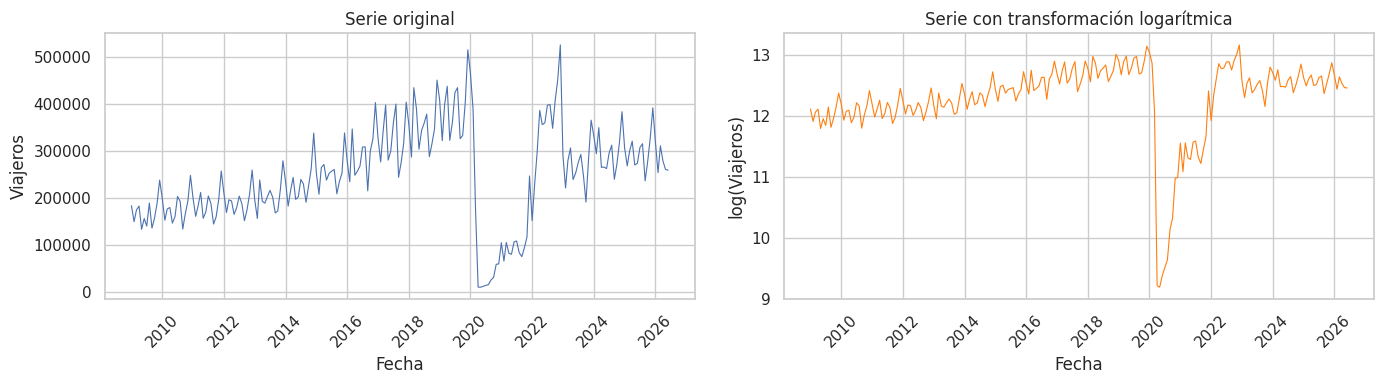

In [13]:
ts_log = np.log(ts)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ts.index, ts.values, linewidth=0.8)
axes[0].set_title("Serie original")
axes[0].set_ylabel("Viajeros")

axes[1].plot(ts_log.index, ts_log.values, linewidth=0.8, color="tab:orange")
axes[1].set_title("Serie con transformación logarítmica")
axes[1].set_ylabel("log(Viajeros)")

for ax in axes:
    ax.set_xlabel("Fecha")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{FIGS}/comparacion_log.png", dpi=150, bbox_inches="tight")
plt.show()

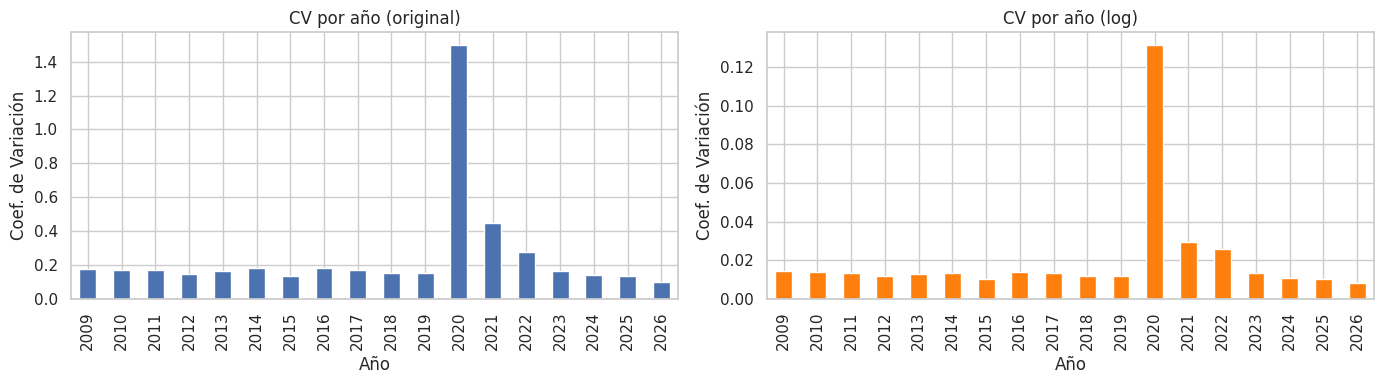

In [14]:
# Comparación de variabilidad: coeficiente de variación por año
cv_original = ts.groupby(ts.index.year).std() / ts.groupby(ts.index.year).mean()
cv_log = ts_log.groupby(ts_log.index.year).std() / ts_log.groupby(ts_log.index.year).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
cv_original.plot(kind="bar", ax=axes[0], title="CV por año (original)")
cv_log.plot(kind="bar", ax=axes[1], title="CV por año (log)", color="tab:orange")
for ax in axes:
    ax.set_xlabel("Año")
    ax.set_ylabel("Coef. de Variación")
plt.tight_layout()
plt.savefig(f"{FIGS}/cv_por_anio.png", dpi=150, bbox_inches="tight")
plt.show()

**Análisis de transformación:**

- Al comparar la serie original con su transformación logarítmica, se observa que el log **estabiliza parcialmente la varianza**, comprimiendo las oscilaciones de mayor amplitud en los años recientes.
- El coeficiente de variación por año confirma que la varianza relativa es más estable después de la transformación logarítmica.
- **Conclusión:** Se recomienda aplicar la transformación logarítmica para mejorar el supuesto de homocedasticidad (varianza constante), lo cual es importante para los modelos ARIMA y las pruebas de estacionariedad.

### e. Estacionariedad en media

**i. Gráfico de autocorrelación (ACF)**

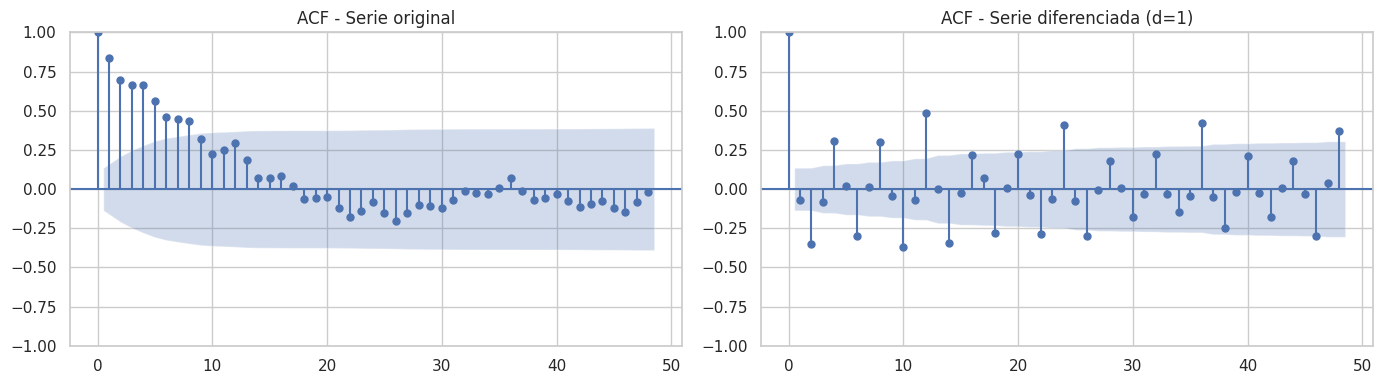

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(ts, lags=48, ax=axes[0], title="ACF - Serie original")
plot_acf(ts.diff().dropna(), lags=48, ax=axes[1], title="ACF - Serie diferenciada (d=1)")

plt.tight_layout()
plt.savefig(f"{FIGS}/acf_original_vs_diff.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación de la ACF:**

- En la **serie original**, los valores de autocorrelación decaen **muy lentamente** a medida que aumentan los rezagos. Este comportamiento es una señal clásica de **no estacionariedad en media**: la serie "recuerda" su pasado durante mucho tiempo porque la tendencia genera autocorrelación persistente.
- En la **serie diferenciada** (d=1), la autocorrelación cae **rápidamente** hacia cero, indicando que la diferenciación ha eliminado la tendencia y la serie resultante se aproxima a una estacionaria en media.
- Esto confirma que es necesario aplicar al menos **una diferenciación** (d=1) para lograr estacionariedad en media.

**ii. Prueba de Dickey-Fuller Aumentada (ADF)**

In [16]:
adf_result = adfuller(ts, autolag="AIC")

print("=" * 50)
print("Prueba de Dickey-Fuller Aumentada (ADF)")
print("=" * 50)
print(f"Estadístico ADF:  {adf_result[0]:.4f}")
print(f"p-value:          {adf_result[1]:.4f}")
print(f"Número de rezagos usados: {adf_result[2]}")
print(f"Número de observaciones:  {adf_result[3]}")
print("\nValores críticos:")
for nivel, valor in adf_result[4].items():
    print(f"  {nivel}: {valor:.4f}")
print("\n" + "=" * 50)

if adf_result[1] > 0.10:
    print("CONCLUSIÓN: p-value > 0.10 → No se rechaza H₀ → La serie NO es estacionaria en media.")
elif adf_result[1] > 0.05:
    print("CONCLUSIÓN: 0.05 < p-value ≤ 0.10 → Resultado borderline: no se rechaza H₀ al 5%.")
    print("La serie podría no ser estacionaria. La ACF sugiere no estacionariedad.")
else:
    print("CONCLUSIÓN: p-value ≤ 0.05 → Se rechaza H₀ → La serie ES estacionaria en media (al 5%).")
    print("Sin embargo, observe el estadístico ADF vs los valores críticos para mayor contexto.")

Prueba de Dickey-Fuller Aumentada (ADF)
Estadístico ADF:  -3.0702
p-value:          0.0288
Número de rezagos usados: 12
Número de observaciones:  197

Valores críticos:
  1%: -3.4640
  5%: -2.8763
  10%: -2.5747

CONCLUSIÓN: p-value ≤ 0.05 → Se rechaza H₀ → La serie ES estacionaria en media (al 5%).
Sin embargo, observe el estadístico ADF vs los valores críticos para mayor contexto.


In [17]:
# Verificación: ADF sobre la serie diferenciada
adf_diff = adfuller(ts.diff().dropna(), autolag="AIC")

print("=" * 50)
print("Prueba ADF sobre serie diferenciada (d=1)")
print("=" * 50)
print(f"Estadístico ADF:  {adf_diff[0]:.4f}")
print(f"p-value:          {adf_diff[1]:.4f}")
print("\nValores críticos:")
for nivel, valor in adf_diff[4].items():
    print(f"  {nivel}: {valor:.4f}")
print("\n" + "=" * 50)

if adf_diff[1] > 0.05:
    print("CONCLUSIÓN: p-value > 0.05 → La serie diferenciada NO es estacionaria.")
else:
    print("CONCLUSIÓN: p-value ≤ 0.05 → La serie diferenciada SÍ es estacionaria en media.")

Prueba ADF sobre serie diferenciada (d=1)
Estadístico ADF:  -4.0378
p-value:          0.0012

Valores críticos:
  1%: -3.4640
  5%: -2.8763
  10%: -2.5747

CONCLUSIÓN: p-value ≤ 0.05 → La serie diferenciada SÍ es estacionaria en media.


**Resumen del análisis de estacionariedad en media:**

1. La **ACF de la serie original** muestra un decaimiento lento, evidencia clásica de no estacionariedad en media.
2. La **prueba ADF** arroja un p-value borderline (~0.03), lo que significa que se rechaza H₀ al nivel del 5%, pero el estadístico ADF (-3.07) está apenas por encima del valor crítico al 1% (-3.46). Esto indica que la serie **podría considerarse estacionaria al 5%**, pero la evidencia visual de la ACF sugiere lo contrario.
3. Tras aplicar **una diferenciación (d=1)**, la prueba ADF da un p-value << 0.01 y la ACF muestra caída rápida, confirmando estacionariedad clara.
4. **Acción recomendada:** Dado el comportamiento borderline de la serie original y la evidencia visual de la ACF, se recomienda aplicar **d = 1** (una diferenciación de primer orden) para garantizar la estacionariedad en media antes de modelar con ARIMA.

## Construcción de la Serie Libre: Viajeros por Vía Aérea

Como segunda serie (categoría **Vías de ingreso**), se construye la serie mensual de viajeros que ingresaron por **vía Aérea**. Se sigue el mismo procedimiento usado para `ts` (agregación mensual con `Año`/`Mes cod` y reindexado como serie de tiempo con frecuencia `MS`).

*Nota:* para la entrega final falta construir las series de **Terrestre** y **Marítima** con el mismo procedimiento, filtrando `df[df["Vía"] == "Terrestre"]` y `df[df["Vía"] == "Marítima"]` respectivamente.

In [ ]:
# Agregación mensual de viajeros que ingresaron por Vía Aérea
mensual_aerea = (df[df["Vía"] == "Aérea"]
                  .groupby(["Año", "Mes cod"])["Viajero"]
                  .sum()
                  .reset_index())

fechas_aerea = pd.to_datetime(dict(year=mensual_aerea["Año"], month=mensual_aerea["Mes cod"], day=1))
ts_aerea = pd.Series(
    mensual_aerea["Viajero"].values,
    index=pd.DatetimeIndex(fechas_aerea, freq="MS"),
    name="viajeros_via_aerea",
)

print(f"Observaciones: {len(ts_aerea)}")
ts_aerea.head(10)

### a. Inicio, fin y frecuencia de la serie

In [ ]:
print(f"Inicio:  {ts_aerea.index[0]:%B %Y}")
print(f"Fin:     {ts_aerea.index[-1]:%B %Y}")
print(f"Frecuencia: {ts_aerea.index.freqstr}")
print(f"Total de observaciones: {len(ts_aerea)}")

### b. Gráfico de la serie

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ts_aerea.plot(ax=ax, color="darkcyan")
ax.set_title("Viajeros por Vía Aérea - Serie mensual (2009-2026)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de viajeros")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(f"{FIGS}/serie_aerea_grafico.png", dpi=150, bbox_inches="tight")
plt.show()